# Adult Income Data Analysis & Exploratory Data Analysis (EDA)

## 1. Project Overview

This notebook performs exploratory data analysis on the cleaned UCI Adult Income dataset.

The analysis focuses on demographic, education, and work-related characteristics associated with annual income above USD 50K.

This is descriptive analysis. The observed relationships represent associations in this historical dataset and do not establish causation.

In [24]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project folders
figures_dir = Path("../reports/figures")
tables_dir = Path("../reports/tables")

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# Visual settings
PROJECT_COLORS = {
    "<=50K": "#2F5597",
    ">50K": "#2A9D8F"
}

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

## 2. Import Libraries 

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Load Cleaned Dataset

In [26]:
from pathlib import Path

processed_file = Path("../data/processed/adult_income_cleaned.csv")

df = pd.read_csv(processed_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (48842, 20)


## 4. Dataset Overview

The cleaned dataset contains the combined UCI Adult training and test records.

This section checks the dataset dimensions, columns, data types, missing values, and duplicate rows before beginning the EDA.

In [27]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (48842, 20)

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income', 'source_split', 'high_income', 'age_group', 'hours_group', 'net_capital']

Data types:
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
source_split        str
high_income       int64
age_group           str
hours_group         str
net_capital       int64
dtype: object

Missing values:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      

## 5. Overall Income Distribution

The target variable `income` contains two categories: `<=50K` and `>50K`.

This section measures the distribution of income groups in the dataset.

In [28]:
income_counts = df["income"].value_counts()

income_percent = (
    df["income"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Income counts:")
print(income_counts)

print("\nIncome percentages:")
print(income_percent)

Income counts:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Income percentages:
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


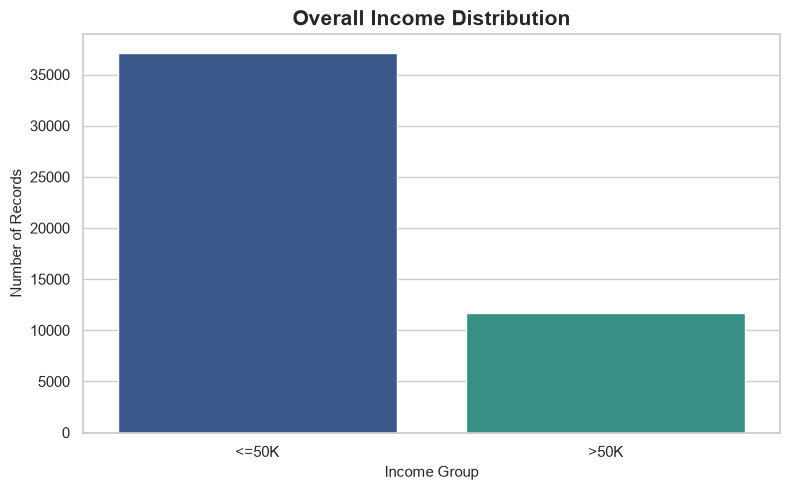

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="income",
    order=["<=50K", ">50K"],
    hue="income",
    palette=PROJECT_COLORS,
    legend=False
)

plt.title("Overall Income Distribution")
plt.xlabel("Income Group")
plt.ylabel("Number of Records")
plt.tight_layout()

plt.savefig(figures_dir / "overall_income_distribution.png", dpi=300)
plt.show()

## 6. Income by Sex

This section compares the proportion of individuals earning above USD 50K across sex categories.

In [30]:
sex_income = pd.crosstab(
    df["sex"],
    df["income"],
    normalize="index").mul(100).round(2)


print(sex_income)

income  <=50K   >50K
sex                 
Female  89.07  10.93
Male    69.62  30.38


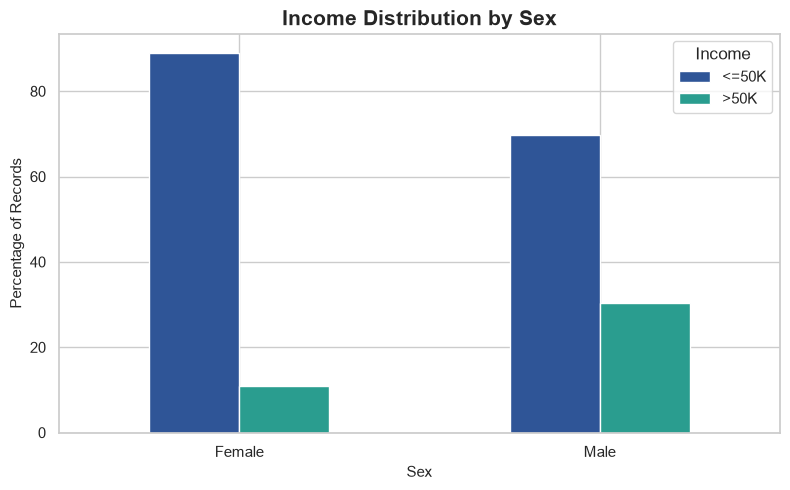

In [31]:
sex_income[["<=50K", ">50K"]].plot(
    kind="bar",
    figsize=(8, 5),
    color=[PROJECT_COLORS["<=50K"], PROJECT_COLORS[">50K"]]
)

plt.title("Income Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=0)
plt.legend(title="Income")
plt.tight_layout()

plt.savefig(figures_dir / "income_by_sex.png", dpi=300)
plt.show()

## 7. Income by Education

This section compares the proportion of individuals earning above USD 50K across education categories.

In [32]:
education_income = pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
).mul(100).round(2)

education_income = education_income.sort_values(
    ">50K",
    ascending=True
)

print(education_income)

income        <=50K   >50K
education                 
Preschool     98.80   1.20
1st-4th       96.76   3.24
11th          94.92   5.08
5th-6th       94.70   5.30
9th           94.58   5.42
10th          93.74   6.26
7th-8th       93.51   6.49
12th          92.69   7.31
HS-grad       84.14  15.86
Some-college  81.04  18.96
Assoc-voc     74.67  25.33
Assoc-acdm    74.20  25.80
Bachelors     58.72  41.28
Masters       45.09  54.91
Doctorate     27.44  72.56
Prof-school   26.02  73.98


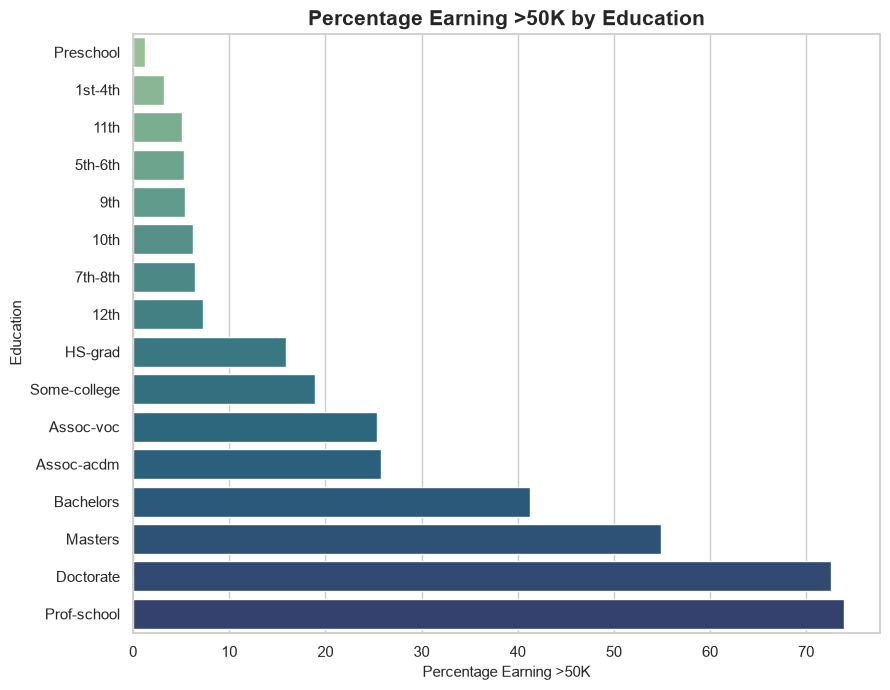

In [33]:
plt.figure(figsize=(9, 7))

sns.barplot(
    x=education_income[">50K"],
    y=education_income.index,
    hue=education_income.index,
    palette="crest",
    legend=False
)

plt.title("Percentage Earning >50K by Education")
plt.xlabel("Percentage Earning >50K")
plt.ylabel("Education")
plt.tight_layout()

plt.savefig(figures_dir / "income_by_education.png", dpi=300)


plt.show()

## 8. Income by Occupation

This section compares the proportion of individuals earning above USD 50K across occupation categories.

In [34]:
occupation_income = pd.crosstab(
    df["occupation"],
    df["income"],
    normalize="index"
).mul(100).round(2)

occupation_income = occupation_income.sort_values(
    by=">50K",
    ascending=True
)

occupation_income

income,<=50K,>50K
occupation,,
Priv-house-serv,98.76,1.24
Other-service,95.86,4.14
Handlers-cleaners,93.34,6.66
Unknown,90.57,9.43
Farming-fishing,88.39,11.61
Machine-op-inspct,87.69,12.31
Adm-clerical,86.31,13.69
Transport-moving,79.58,20.42
Craft-repair,77.37,22.63


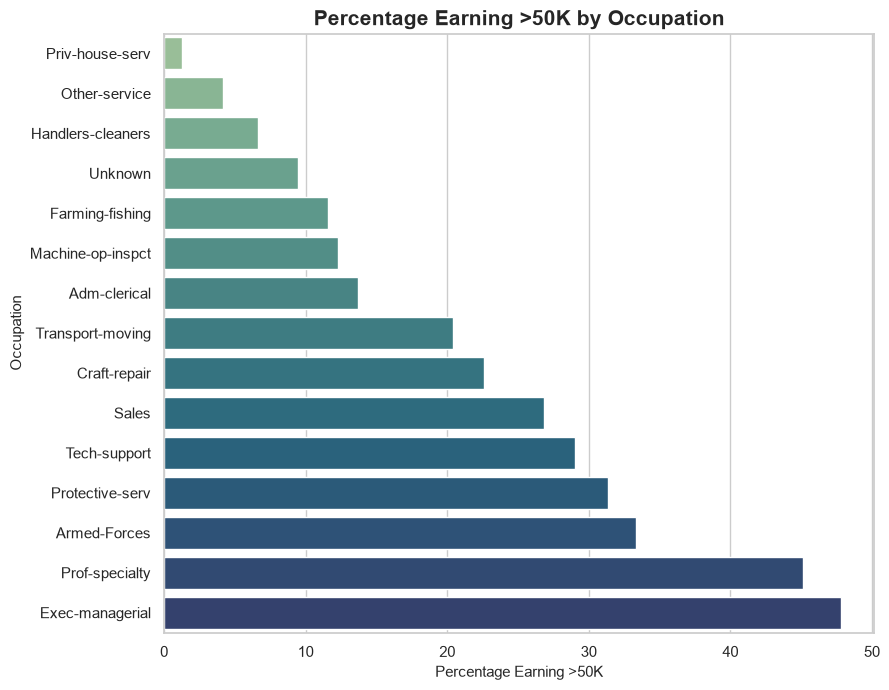

In [35]:
plt.figure(figsize=(9, 7))

sns.barplot(
    x=occupation_income[">50K"],
    y=occupation_income.index,
    hue=occupation_income.index,
    palette="crest",
    legend=False
)

plt.title("Percentage Earning >50K by Occupation")
plt.xlabel("Percentage Earning >50K")
plt.ylabel("Occupation")
plt.tight_layout()

plt.savefig(figures_dir / "income_by_occupation.png", dpi=300)

plt.show()

## 9. Income by Workclass

This section compares the proportion of individuals earning above USD 50K across different workclass categories.

In [36]:
workclass_income = pd.crosstab(
    df["workclass"],
    df["income"],
    normalize="index"
).mul(100).round(2)

workclass_income = workclass_income.sort_values(
    by=">50K",
    ascending=True
)

workclass_income

income,<=50K,>50K
workclass,,
Never-worked,100.00,0.00
Unknown,90.53,9.47
Without-pay,90.48,9.52
Private,78.21,21.79
State-gov,73.25,26.75
Self-emp-not-inc,72.11,27.89
Local-gov,70.44,29.56
Federal-gov,60.82,39.18
Self-emp-inc,44.66,55.34


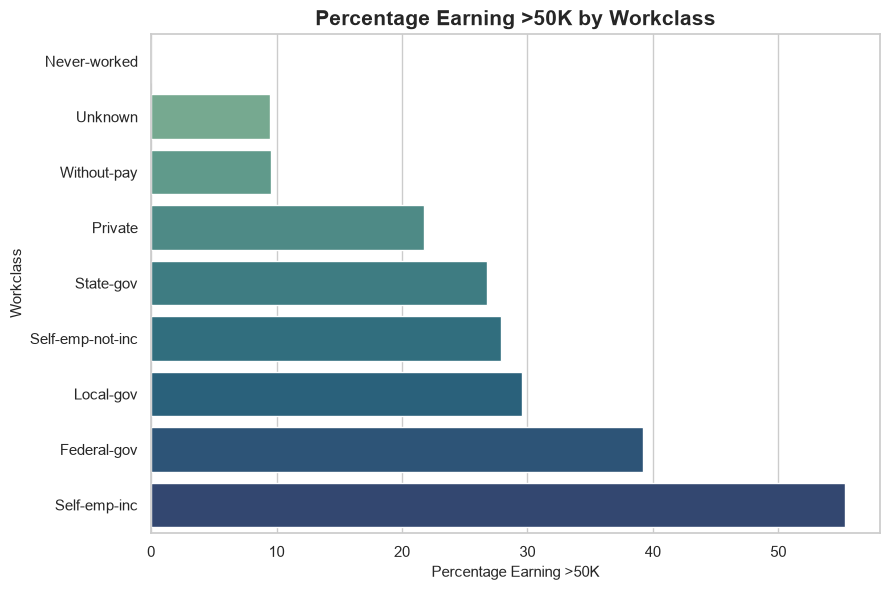

In [37]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=workclass_income[">50K"],
    y=workclass_income.index,
    hue=workclass_income.index,
    palette="crest",
    legend=False
)

plt.title("Percentage Earning >50K by Workclass")
plt.xlabel("Percentage Earning >50K")
plt.ylabel("Workclass")
plt.tight_layout()

plt.savefig(figures_dir / "income_by_workclass.png", dpi=300)
plt.show()

## 10. Income by Age Group

This section compares the proportion of individuals earning above USD 50K across different age groups.

In [38]:
age_income = pd.crosstab(
    df["age_group"],
    df["income"],
    normalize="index"
).mul(100).round(2)

age_income = age_income.sort_values(
    by=">50K",
    ascending=True
)

age_income

income,<=50K,>50K
age_group,,
17-25,98.24,1.76
26-35,81.30,18.70
66+,80.20,19.80
56-65,68.59,31.41
36-45,65.44,34.56
46-55,60.76,39.24


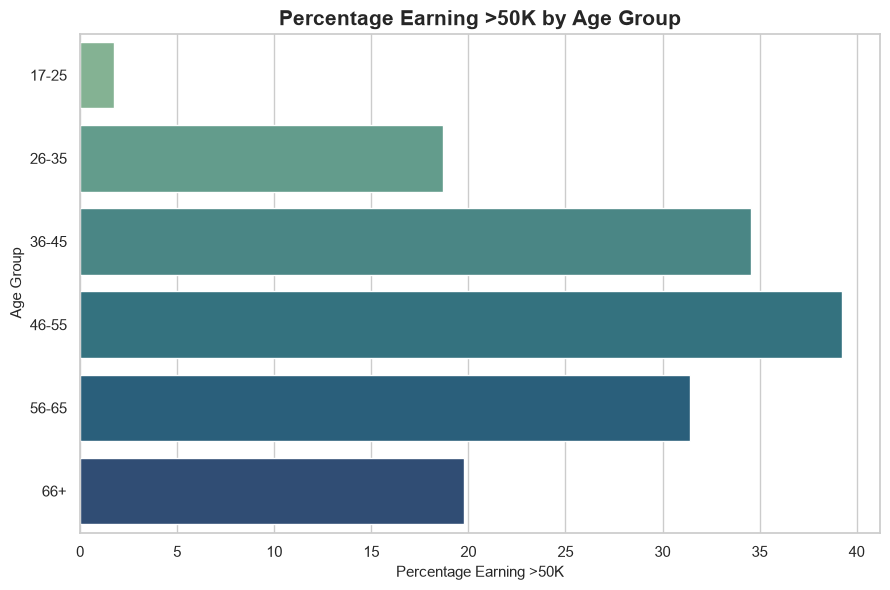

In [39]:
age_order = ["17-25", "26-35", "36-45", "46-55", "56-65", "66+"]

age_income = age_income.reindex(age_order)

plt.figure(figsize=(9, 6))

sns.barplot(
    x=age_income[">50K"],
    y=age_income.index,
    hue=age_income.index,
    palette="crest",
    legend=False
)

plt.title("Percentage Earning >50K by Age Group")
plt.xlabel("Percentage Earning >50K")
plt.ylabel("Age Group")
plt.tight_layout()

plt.savefig(
    figures_dir / "income_by_age_group.png",
    dpi=300
)

plt.show()

## 11. Weekly Working Hours by Income Group

This section compares the distribution of weekly working hours between individuals earning at or below USD 50K and those earning above USD 50K.

In [47]:
hours_order = ["<=20", "21-34", "35-40", "41-49", "50-59", "60+"]

df["hours_group"] = pd.Categorical(
    df["hours_group"],
    categories=hours_order,
    ordered=True
)
hours_income = pd.crosstab(
    df["hours_group"],
    df["income"],
    normalize="columns"
).mul(100).round(2)

hours_income

income,<=50K,>50K
hours_group,,
<=20,11.17,2.58
21-34,9.86,2.39
35-40,55.79,45.91
41-49,8.22,13.84
50-59,8.77,22.00
60+,6.19,13.29


<Figure size 900x600 with 0 Axes>

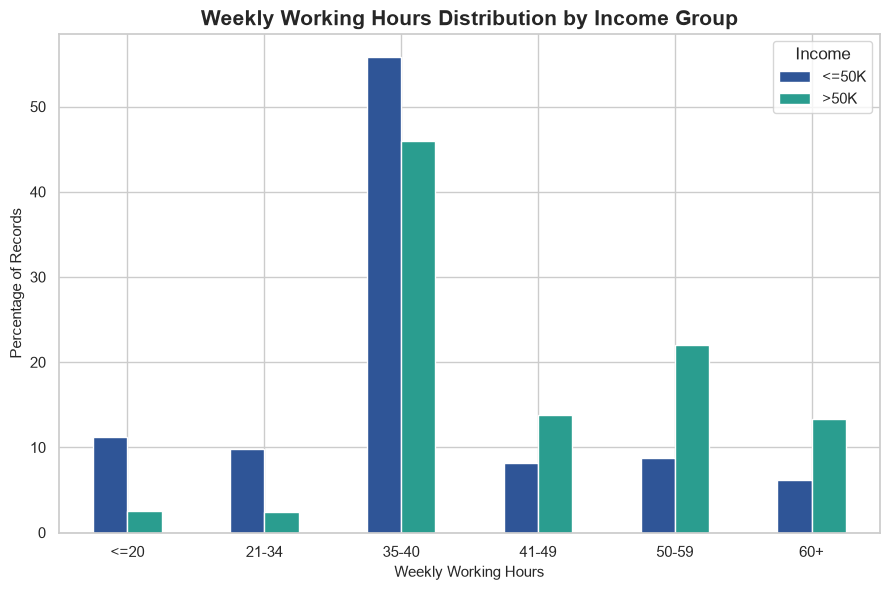

In [41]:
hours_order = ["<=20", "21-34", "35-40", "41-49", "50-59", "60+"]

hours_income = hours_income.reindex(hours_order)

plt.figure(figsize=(9, 6))

hours_income.plot(
    kind="bar",
    figsize=(9, 6),
    color=[
        PROJECT_COLORS["<=50K"],
        PROJECT_COLORS[">50K"]
    ]
)

plt.title("Weekly Working Hours Distribution by Income Group")
plt.xlabel("Weekly Working Hours")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=0)
plt.legend(title="Income")
plt.tight_layout()

plt.savefig(
    figures_dir / "weekly_hours_by_income.png",
    dpi=300
)
plt.show()

## 12. Numeric Relationships with Income

This section examines the relationships between selected numeric variables and the high-income indicator. Correlation measures association and does not imply causation.

In [42]:
numeric_columns = [
    "age",
    "education_num",
    "hours_per_week",
    "capital_gain",
    "capital_loss",
    "net_capital",
    "high_income"
]

correlation = df[numeric_columns].corr()

correlation["high_income"].sort_values(ascending=False)

high_income       1.000000
education_num     0.332613
age               0.230369
hours_per_week    0.227687
capital_gain      0.223013
net_capital       0.214356
capital_loss      0.147554
Name: high_income, dtype: float64

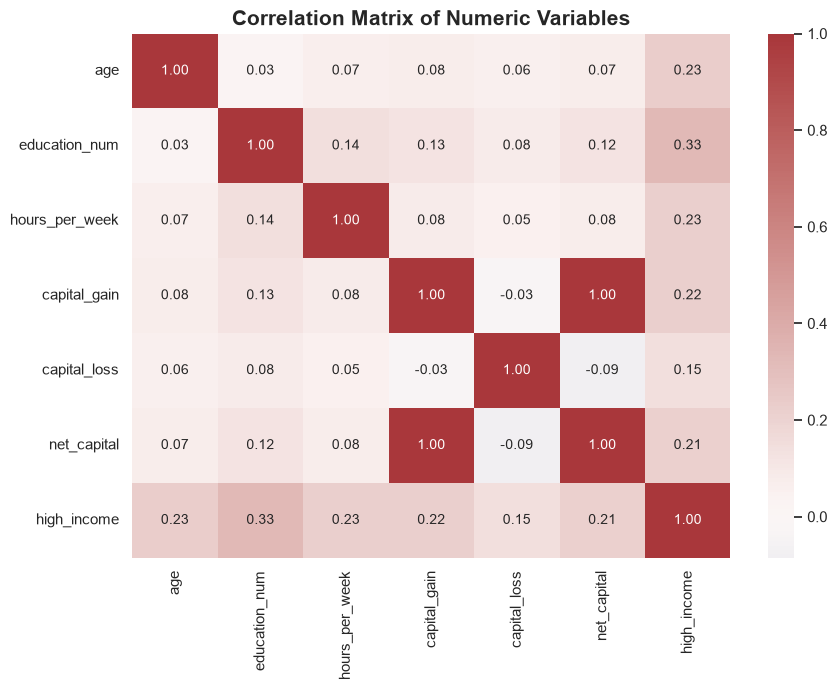

In [43]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
)

plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()

plt.savefig(
    figures_dir / "correlation_heatmap.png",
    dpi=300
)

plt.show()

## 13. Capital Gain and Capital Loss by Income Group

This section compares the presence of non-zero capital gains and capital losses between the two income groups.

In [44]:
capital_summary = pd.DataFrame({
    "Capital Gain > 0 (%)": [
        (df.loc[df["income"] == "<=50K", "capital_gain"] > 0).mean() * 100,
        (df.loc[df["income"] == ">50K", "capital_gain"] > 0).mean() * 100
    ],
    "Capital Loss > 0 (%)": [
        (df.loc[df["income"] == "<=50K", "capital_loss"] > 0).mean() * 100,
        (df.loc[df["income"] == ">50K", "capital_loss"] > 0).mean() * 100
    ]
}, index=["<=50K", ">50K"]).round(2)

capital_summary

,Capital Gain > 0 (%),Capital Loss > 0 (%)
<=50K,4.16,3.06
>50K,21.31,9.79


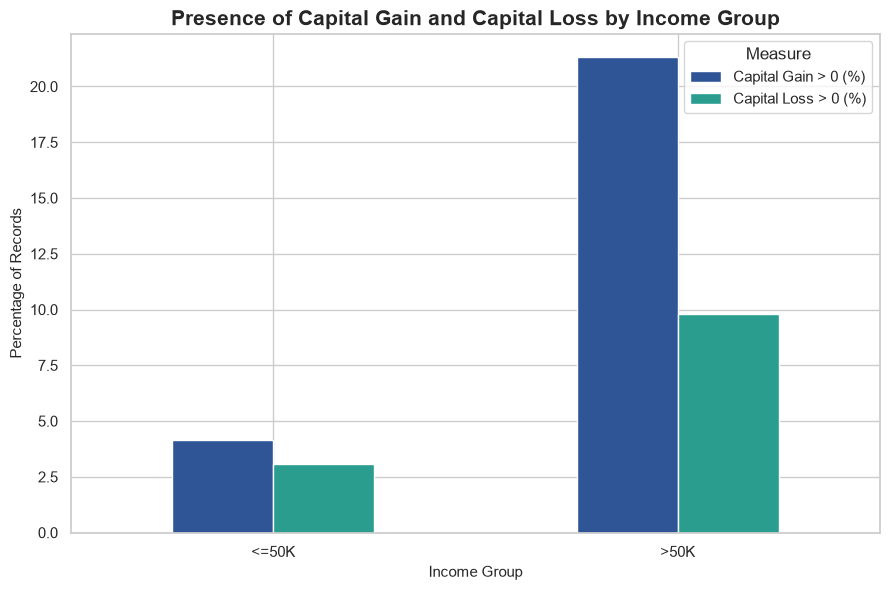

In [45]:
capital_summary.plot(
    kind="bar",
    figsize=(9, 6),
    color=["#2F5597", "#2A9D8F"]
)

plt.title("Presence of Capital Gain and Capital Loss by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=0)
plt.legend(title="Measure")
plt.tight_layout()

plt.savefig(
    figures_dir / "capital_income_comparison.png",
    dpi=300
)

plt.show()

## 14. Key Findings

- The dataset contains 48,842 records, with 23.93% belonging to the >50K income group and 76.07% belonging to the <=50K group.
- Income distribution differs by sex, with the proportion of >50K income being higher among males than females in this dataset.
- Education level shows a clear positive association with higher income. The proportion earning >50K is higher among groups with higher education levels.
- Income distribution also varies across occupations and workclasses, with some categories having substantially higher >50K proportions than others.
- The proportion earning >50K generally increases across the middle and older working-age groups, with the highest observed rate in the 46-55 age group.
- Higher weekly working hours are more common among the >50K income group, particularly in the 50-59 and 60+ hour categories.
- Among the numeric variables examined, education_num has the strongest positive correlation with high_income (0.33), followed by age (0.23), hours_per_week (0.23), and capital_gain (0.22).
- Non-zero capital gains and capital losses are more frequently observed in the >50K income group than in the <=50K group.
- These findings describe associations in the dataset and should not be interpreted as evidence of causation.

## 15. Limitations

- This analysis is descriptive and identifies associations rather than causal relationships.
- The Adult dataset contains demographic, education, and employment-related information, but it does not include every factor that may influence income.
- The dataset contains duplicate records. These were retained because there is no unique identifier to determine whether they represent valid repeated observations or duplicate entries.
- Missing categorical values were grouped under "Unknown", which preserves the records but may affect comparisons for those categories.
- The income threshold is specific to the dataset and represents annual income above or below USD 50K.
- Some categories contain relatively few observations, so their percentages should be interpreted with caution.
- The analysis is based on historical dataset records and may not represent current income patterns.
- Correlation values describe linear association between numeric variables and the income indicator and should not be interpreted as causation.

## 16. Conclusion

This exploratory analysis examined demographic, education, employment, and work-related characteristics associated with income above USD 50K in the UCI Adult Income dataset.

The analysis found differences in the >50K income proportion across education levels, occupations, workclasses, age groups, sex, and weekly working-hour groups. Among the numeric variables examined, education_num showed the strongest positive correlation with the high_income indicator.

The analysis also showed that non-zero capital gains and capital losses occurred more frequently among records in the >50K income group.

Overall, the findings provide a descriptive understanding of patterns in the dataset and can serve as a foundation for further statistical analysis or predictive modeling. The results should be interpreted as associations within this dataset rather than causal relationships.

In [46]:
from pathlib import Path

tables_dir = Path("../reports/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

# Overall income summary
income_summary = (
    df["income"]
    .value_counts()
    .rename_axis("income")
    .reset_index(name="count")
)

income_summary["percentage"] = (
    income_summary["count"] / len(df) * 100
).round(2)

income_summary.to_csv(
    tables_dir / "income_summary.csv",
    index=False
)

# Income by sex
sex_income.to_csv(
    tables_dir / "income_by_sex.csv"
)

# Income by education
education_income.to_csv(
    tables_dir / "income_by_education.csv"
)

# Income by occupation
occupation_income.to_csv(
    tables_dir / "income_by_occupation.csv"
)

# Income by workclass
workclass_income.to_csv(
    tables_dir / "income_by_workclass.csv"
)

# Income by age group
age_income.to_csv(
    tables_dir / "income_by_age_group.csv"
)

# Weekly hours distribution
hours_income.to_csv(
    tables_dir / "weekly_hours_by_income.csv"
)

# Capital gain/loss summary
capital_summary.to_csv(
    tables_dir / "capital_gain_loss_by_income.csv"
)

print("Analysis tables exported successfully!")

Analysis tables exported successfully!
